# Cost Prediction Regression

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load the dataset
df.head() # Display the first few rows of the dataset


,member_id,age,gender,region,plan_type,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed,engagement_group,age_group,high_cost_member,has_acute_utilization,chronic_burden_group
0,M00001,69,Female,Rural,DSNP,3,72.6,1,1,2634.13,0,Q4,65-79,True,1,Moderate
1,M00002,32,Female,Suburban,Medicare Advantage,0,71.5,0,1,1632.38,1,Q4,18-34,False,1,Low
2,M00003,89,Male,Suburban,Medicaid,2,32.6,0,0,978.36,1,Q1,80+,False,0,Moderate
3,M00004,78,Male,Suburban,Medicare Advantage,7,56.0,3,0,2761.83,1,Q3,65-79,True,1,High
4,M00005,38,Female,Urban,DSNP,2,42.2,0,1,2001.45,1,Q1,35-49,True,1,Moderate


## 3. Define Target and Features

In [3]:
target = "monthly_cost" # Define the target variable
X = df.drop(columns=["member_id", target]) # Define the features -- It has no real predictive meaning.
y = df[target] # Define the target variable



## 4.Prepare Modeling Data

In [4]:
categorical_cols = X.select_dtypes(include=["str", "category"]).columns.tolist() # Identify categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist() # Identify numeric columns

print("Categorical columns:", categorical_cols)
print("Numeric Columns:", numeric_cols)



Categorical columns: ['gender', 'region', 'plan_type', 'engagement_group', 'age_group', 'chronic_burden_group']
Numeric Columns: ['age', 'chronic_condition_count', 'engagement_score', 'ed_visits', 'ip_admits', 'awv_completed', 'has_acute_utilization']


In [5]:
# Build the preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(drop = "first", handle_unknown= "ignore"), categorical_cols), # Preprocess categorical columns - drop = "First" to avoid redundant dummy columns
        ("num", "passthrough", numeric_cols)
    ]
)



## 5. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data into training and testing sets

# No Stratify =  y because stratify is usually for classification targets & monthly_cost is continuous.

## 6. Build Baseline Linear Regression Model

In [7]:
lr_model = Pipeline(steps = [ ("preprocessor", preprocessor) , ("model", LinearRegression()) ]) # Create a pipeline that combines the preprocessor and the linear regression model

lr_model.fit(X_train, y_train) # Fit the model to the training data


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 7.Evaluate Regression Performance 

In [8]:
# Make Predictions

y_pred = lr_model.predict(X_test) # Predict the target variable for the test set

# Calculate Metrics

mae = mean_absolute_error(y_test, y_pred) # Calculate Mean Absolute Error
mse = mean_squared_error(y_test, y_pred) # Calculate Mean Squared Error
rmse = np.sqrt(mse) # Calculate Root Mean Squared Error
r2 = r2_score(y_test, y_pred) # Calculate R-squared

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-Squared:", r2)







MAE: 87.26858423029688
MSE: 12616.880455010196
RMSE: 112.32488795903691
R-Squared: 0.9736060887332136


## 8. Interpret Regression Coefficients

In [9]:
ohe = lr_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols) # Get the names of the encoded categorical features
all_feature_names = list(encoded_cat_features) + numeric_cols # Combine encoded categorical feature names with numeric feature names

# Get Coefficients

coefficients = lr_model.named_steps["model"].coef_ # Get the coefficients from the linear regression model
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df["absolute_coefficient"] = coef_df["Coefficient"].abs() # Calculate the absolute value of the coefficients
coef_df = coef_df.sort_values(by="absolute_coefficient", ascending=False) # Sort the coefficients by absolute value

coef_df.head(15)

,Feature,Coefficient,absolute_coefficient
18,ip_admits,862.528911,862.528911
3,plan_type_Medicaid,-386.895062,386.895062
4,plan_type_Medicare Advantage,-230.625265,230.625265
17,ed_visits,208.732675,208.732675
15,chronic_condition_count,187.691071,187.691071
7,engagement_group_Q4,36.833844,36.833844
2,region_Urban,-21.643263,21.643263
12,chronic_burden_group_Low,16.638022,16.638022
13,chronic_burden_group_Moderate,16.248563,16.248563
20,has_acute_utilization,15.929786,15.929786


## 9. Review Predictions Errors

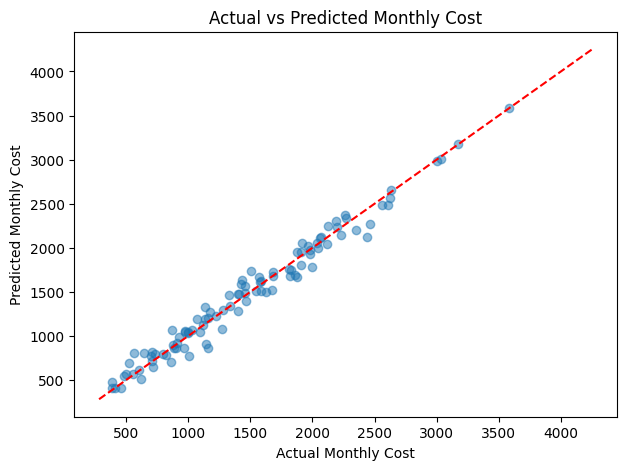

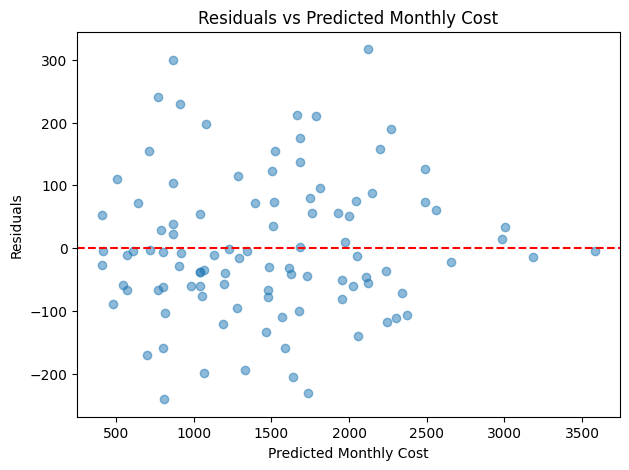

,actual_monthly_cost,predicted_monthly_cost,residuals
0,383.79,411.307529,-27.517529
1,1904.73,1955.695079,-50.965079
2,2065.52,2120.880492,-55.360492
3,2117.86,2042.995888,74.864112
4,556.52,566.798123,-10.278123
5,1573.75,1674.525065,-100.775065
6,1069.77,1190.110384,-120.340384
7,1983.20,1927.972916,55.227084
8,1919.11,2058.535928,-139.425928
9,1274.96,1077.368285,197.591715


In [10]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5) # Create a scatter plot of actual vs predicted values
plt.xlabel("Actual Monthly Cost") # Label for x-axis
plt.ylabel("Predicted Monthly Cost") # Label for y-axis
plt.title("Actual vs Predicted Monthly Cost") # Title for the plot
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Add a reference line for perfect predictions
plt.show()

# Residuals Plot
residuals = y_test - y_pred # Calculate residuals
plt.figure(figsize=(7,5))
plt.axhline(0, color='red', linestyle='--') # Add a horizontal line at y=0
plt.scatter(y_pred, residuals, alpha=0.5) # Create a scatter plot of predicted values vs residuals
plt.xlabel("Predicted Monthly Cost") # Label for x-axis
plt.ylabel("Residuals") # Label for y-axis
plt.title("Residuals vs Predicted Monthly Cost") # Title for the plot
plt.show()

# Compare a few predictions 

comparison_df = pd.DataFrame({
    "actual_monthly_cost": y_test.values,
    "predicted_monthly_cost": y_pred,
    "residuals" : y_test.values - y_pred
})

comparison_df.head(10)



## 10. Findings

1. A baseline multiple linear regression model was built to predict monthly member cost using demographic, utilization, and engineered features.
2. Utilization-related variables such as ED visits and inpatient admits are expected to show positive associations with monthly cost, 
which is consistent with the synthetic data design if the coefficients are positive.
3. Regression performance should be interpreted using MAE, RMSE, and R2 together rather than any single metric alone.
4. Coefficients describe conditional associations with predicted cost and should not be interpreted as causal effects.
5. Residual review helps identify wheter the linear model is missing non-linear structure or making larger errors for high-cost members. 